<a href="https://colab.research.google.com/github/Aayushsuthar/Machine-Learning-And-Deep-Learning-Labs/blob/main/crop-disease-prediction/01_crop_disease_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Crop Disease Prediction - end-to-end image classification
# Dataset: PlantVillage (via TensorFlow Datasets), no login required
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

ERROR:absl:Detected incompatible Protobuf Gencode/Runtime versions when loading tensorflow_metadata/proto/v0/anomalies.proto: gencode 6.31.1 runtime 5.29.6. Runtime version cannot be older than the linked gencode version. See Protobuf version guarantees at https://protobuf.dev/support/cross-version-runtime-guarantee.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/__init__.py", line 79, in <module>
    from tensorflow_datasets import rlds  # pylint: disable=g-bad-import-order
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/rlds/__init__.py", line 21, in <module>
    from tensorflow_datasets.rlds import envlogger_reader
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/rlds/envlogger_reader.py", line 21, in <module>
    from tensorflow_datasets.core.utils.lazy_imports_utils import tree
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/co

TF version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
!pip install -q -U protobuf tensorflow_datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 23.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.35.1 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.35.1 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.35.1 which is incompatible.


In [4]:
!pip install -q datasets

In [5]:
from datasets import load_dataset

In [6]:
# PlantVillage dataset via Hugging Face Hub (reliable mirror, CC0 license, 54,305 images, 38 classes)
# This is the real, full PlantVillage dataset - the earlier TFDS/Mendeley and TFDS/GCS mirrors were both down (403 errors).
hf_ds = load_dataset("BrandonFors/Plant-Diseases-PlantVillage-Dataset")
print(hf_ds)

README.md:   0%|          | 0.00/6.64k [00:00<?, ?B/s]

data/train-00000-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  321MB            

data/train-00000-of-00002.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  362MB            

data/train-00001-of-00002.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  170MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/43456 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10849 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 43456
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10849
    })
})


In [7]:
# Split off a validation set from train (90/10), keep the provided test set separate
split_ds = hf_ds["train"].train_test_split(test_size=0.1, seed=42)
train_hf = split_ds["train"]
val_hf = split_ds["test"]
test_hf = hf_ds["test"]

label_feature = hf_ds["train"].features["label"]
class_names = label_feature.names
num_classes = len(class_names)

print("Train size:", len(train_hf))
print("Val size:", len(val_hf))
print("Test size:", len(test_hf))
print("Num classes:", num_classes)
print(class_names[:5])

Train size: 39110
Val size: 4346
Test size: 10849
Num classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


In [8]:
# Build a tf.data pipeline that decodes PIL images from the HF dataset on the fly
IMG_SIZE = 128
BATCH_SIZE = 32

def make_generator(hf_dataset):
    def gen():
      for example in hf_dataset:
        image = example["image"].convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        array = np.array(image, dtype=np.float32) / 255.0
        yield array, example["label"]
    return gen

def build_tf_dataset(hf_dataset, shuffle=False):
    output_signature = (tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32), tf.TensorSpec(shape=(), dtype=tf.int64))
    ds = tf.data.Dataset.from_generator(make_generator(hf_dataset), output_signature=output_signature)
    if shuffle:
      ds = ds.shuffle(2000)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds
train_ds = build_tf_dataset(train_hf, shuffle=True)
val_ds = build_tf_dataset(val_hf)
test_ds = build_tf_dataset(test_hf)

for images, labels in train_ds.take(1):
    print("Batch images shape:", images.shape)
    print("Batch labels shape:", labels.shape)

Batch images shape: (32, 128, 128, 3)
Batch labels shape: (32,)


In [9]:
# Model: MobileNetV2 backbone (ImageNet weights, frozen) + a custom classification head.
# Data augmentation is built into the graph so it only applies during training.
data_augmentation = tf.keras.Sequential([tf.keras.layers.RandomFlip("horizontal"), tf.keras.layers.RandomRotation(0.15), tf.keras.layers.RandomZoom(0.15)], name="data_augmentation")

base_model = tf.keras.applications.MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights="imagenet")
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = (x * 2.0) - 1.0
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs, name="crop_disease_classifier")
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "crop_disease_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,595,686 (9.90 MB)

 Trainable params: 337,702 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
# Compile and train the classification head (base model stays frozen for this first pass)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

callbacks = [tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True)]

EPOCHS = 10
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks)

Epoch 1/10
   1223/Unknown 120s 87ms/step - accuracy: 0.6759 - loss: 1.1841

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1223/1223 ━━━━━━━━━━━━━━━━━━━━ 134s 98ms/step - accuracy: 0.7749 - loss: 0.7611 - val_accuracy: 0.8912 - val_loss: 0.3468
Epoch 2/10
1223/1223 ━━━━━━━━━━━━━━━━━━━━ 123s 97ms/step - accuracy: 0.8556 - loss: 0.4562 - val_accuracy: 0.8935 - val_loss: 0.3178
Epoch 3/10
1223/1223 ━━━━━━━━━━━━━━━━━━━━ 122s 96ms/step - accuracy: 0.8694 - loss: 0.4072 - val_accuracy: 0.9149 - val_loss: 0.2632
Epoch 4/10
1223/1223 ━━━━━━━━━━━━━━━━━━━━ 119s 94ms/step - accuracy: 0.8766 - loss: 0.3853 - val_accuracy: 0.9185 - val_loss: 0.2447
Epoch 5/10
1223/1223 ━━━━━━━━━━━━━━━━━━━━ 124s 97ms/step - accuracy: 0.8785 - loss: 0.3754 - val_accuracy: 0.9245 - val_loss: 0.2343
Epoch 6/10
1223/1223 ━━━━━━━━━━━━━━━━━━━━ 122s 96ms/step - accuracy: 0.8828 - loss: 0.3607 - val_accuracy: 0.9241 - val_loss: 0.2327
Epoch 7/10
1223/1223 ━━━━━━━━━━━━━━━━━━━━ 120s 94ms/step - accuracy: 0.8837 - loss: 0.3606 - val_accuracy: 0.9275 - val_loss: 0.2139
Epoch 8/10
1223/1223 ━━━━━━━━━━━━━━━━━━━━ 120s 94ms/step - accuracy: 0.8918 - lo

In [11]:
# Evaluate on the held-out test set (never seen during training or validation)
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test loss: {test_loss:.4f}")

340/340 ━━━━━━━━━━━━━━━━━━━━ 28s 82ms/step - accuracy: 0.9248 - loss: 0.2291
Test accuracy: 0.9248
Test loss: 0.2291


In [12]:
from sklearn.metrics import classification_report, confusion_matrix

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy().tolist())
    y_pred.extend(np.argmax(preds, axis=1).tolist())
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab      0.878     0.857     0.867       126
                                 Apple___Black_rot      0.904     0.984     0.942       124
                          Apple___Cedar_apple_rust      0.957     0.818     0.882        55
                                   Apple___healthy      0.954     0.945     0.950       329
                               Blueberry___healthy      0.890     0.997     0.940       300
          Cherry_(including_sour)___Powdery_mildew      1.000     0.810     0.895       210
                 Cherry_(including_sour)___healthy      0.950     1.000     0.974       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot      0.868     0.647     0.742       102
                       Corn_(maize)___Common_rust_      0.988     0.996     0.992       238
               Corn_(maize)___Northern_Leaf_Blight      0.862     0.954     0.9

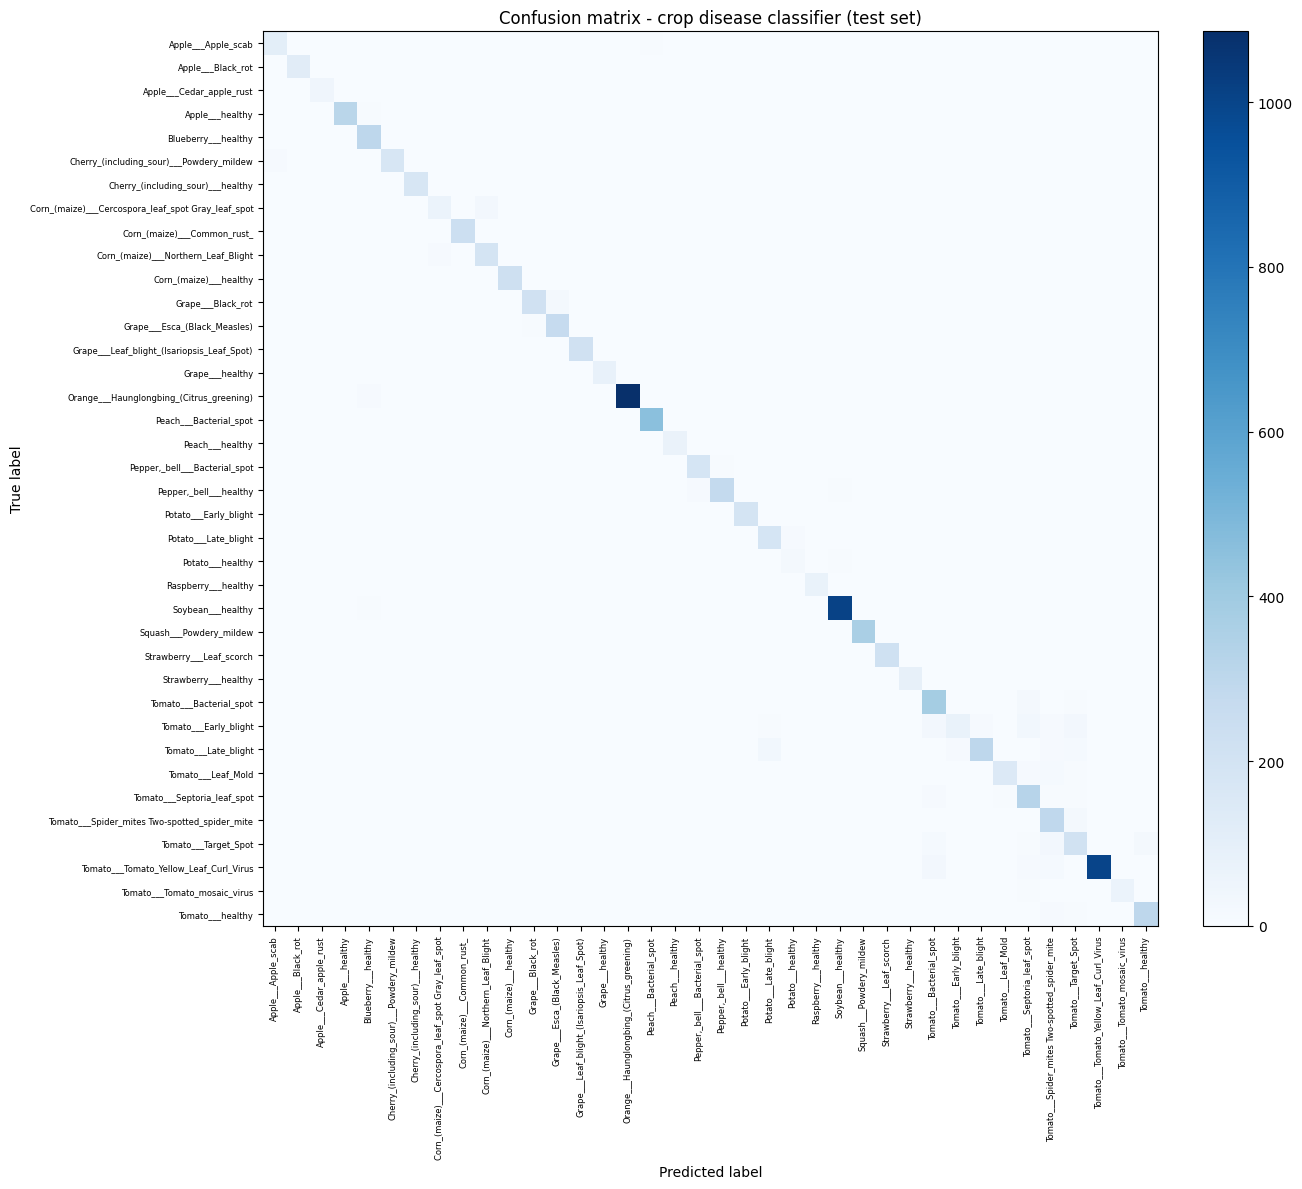

In [13]:
# Confusion matrix heatmap across all 38 classes (real predictions on the held-out test set)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))
plt.imshow(cm, cmap="Blues")
plt.colorbar(fraction=0.046, pad=0.04)
plt.title("Confusion matrix - crop disease classifier (test set)")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(range(num_classes), class_names, rotation=90, fontsize=6)
plt.yticks(range(num_classes), class_names, fontsize=6)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

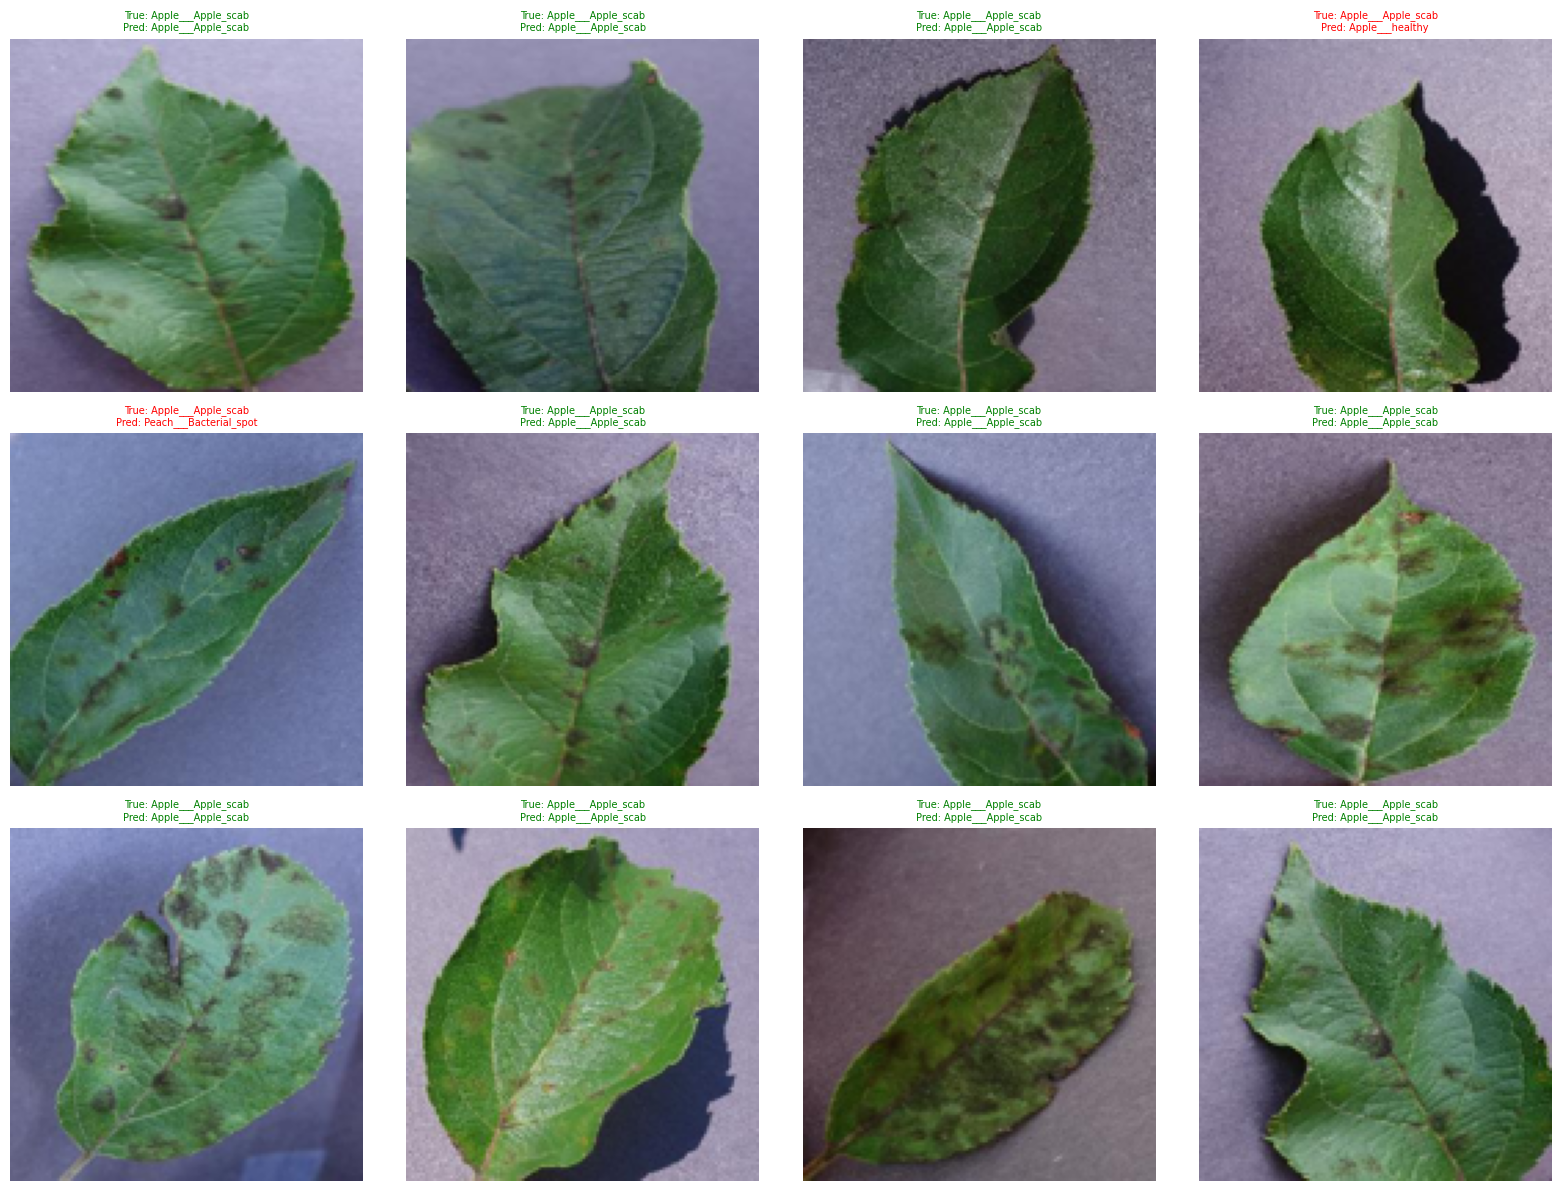

In [14]:
# Real sample predictions on actual test images - green title = correct, red = wrong
plt.figure(figsize=(16, 12))
for images, labels in test_ds.take(1):
    preds = model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)
    for i in range(12):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy())
        true_name = class_names[labels[i].numpy()]
        pred_name = class_names[pred_labels[i]]
        title_color = "green" if pred_labels[i] == labels[i].numpy() else "red"
        plt.title(f"True: {true_name}\nPred: {pred_name}", fontsize=7, color=title_color)
        plt.axis("off")
plt.tight_layout()
plt.savefig("sample_predictions.png", dpi=150)
plt.show()

In [15]:
import json
model.save("crop_disease_classifier.keras")
f = open("class_names.json", "w")
json.dump(class_names, f)
f.close()
print("Saved model to crop_disease_classifier.keras")
print("Saved class names to class_names.json")

Saved model to crop_disease_classifier.keras
Saved class names to class_names.json


In [16]:
import matplotlib.pyplot as plt
for images, labels in test_ds.take(1): demo_batch = images; demo_labels_batch = labels
demo_true_label = class_names[demo_labels_batch[0].numpy()]
demo_preds = model.predict(demo_batch[:1], verbose=0)[0]
demo_predicted_index = int(np.argmax(demo_preds))
demo_predicted_label = class_names[demo_predicted_index]
demo_confidence = float(demo_preds[demo_predicted_index])
print("True label:", demo_true_label)
print("Predicted label:", demo_predicted_label)
print("Confidence:", round(demo_confidence * 100, 2), "%")

True label: Apple___Apple_scab
Predicted label: Apple___Apple_scab
Confidence: 83.03 %
